In [1]:
import re
import os
from glob import glob
from os.path import basename

import numpy as np
import matplotlib.pyplot as plt
import h5py
import time

In [2]:
folder = r"G:\Shared drives\XPCS_2026\data\FCGT_12-15-24\h5"

files = sorted(glob(os.path.join(folder, "*.h5")),
               key=os.path.getmtime)

print(f"Found {len(files)} HDF5 files\n")

for i, f in enumerate(files):
    print(f"{i:3d} : {basename(f)}")

Found 20 HDF5 files

  0 : FCGT_initial_380K_50ms_20images_62faa482-4ffd-4eb7-8f14-59455ce2f750.h5
  1 : FCGT_initial_370K_50ms_50images_f4b6d775-04fb-413f-84ba-e97811ecfe95.h5
  2 : FCGT_initial_365K_50ms_20images_ff58e290-6a97-474a-91ac-860a74328921.h5
  3 : FCGT_initial_360K_10ms_20images_4a557257-5351-46fc-9727-172c475fb335.h5
  4 : FCGT_initial_350K_10ms_20images_073fe2b8-d5e3-45e2-abf1-9e6ad9f244a7.h5
  5 : FCGT_initial_340K_10ms_20images_b226c14d-e92c-462b-9340-d67db6ac50ff.h5
  6 : FCGT_initial_320K_10ms_20images_837710c5-d55b-493b-aaa5-289273ca29eb.h5
  7 : FCGT_initial_310K_10ms_20images_591d1f76-b66b-442d-9021-aca08a9cfa9d.h5
  8 : FCGT_initial_300K_10ms_20images_XMCD_e30274f3-4754-4150-a5da-b1c98104b453.h5
  9 : FCGT_initial_300K_10ms_20images_1b7fce69-29b8-4fde-9b79-bd89f6b8310a.h5
 10 : FCGT_after_cooling_300K_10ms_20images_1c09e527-6db8-410d-9802-f8682e159e7b.h5
 11 : FCGT_363K_XPCS_300ms_1900images_640readout_310d3268-f4c8-48b6-9cb6-9bcc8161909a.h5
 12 : FCGT_350K_XMCD_

In [3]:
file_idx = 0

file = files[file_idx]

with h5py.File(file, "r") as f:

    print("Top level:")
    print(list(f.keys()))

    print("\nentry1:")
    print(list(f["entry1"].keys()))

    print("\ninstrument_1:")
    print(list(f["entry1"]["instrument_1"].keys()))

    print("\ndetector_1:")
    print(list(f["entry1"]["instrument_1"]["detector_1"].keys()))

    print("\nlabview_data:")
    print(list(f["entry1"]["instrument_1"]["labview_data"].keys()))

Top level:
['entry1']

entry1:
['end_time', 'instrument_1', 'run_id', 'sample_1', 'start_time']

instrument_1:
['detector_1', 'labview_data', 'name', 'source_1']

detector_1:
['count_time', 'data', 'description', 'detector_readout_time', 'distance', 'exposures', 'period', 'x_pixel_size', 'y_pixel_size']

labview_data:
['CAEN3', 'CAEN3_user_setpoint', 'CAEN4', 'CAEN4_user_setpoint', 'DIAG112_Diode_diode', 'DetectorDiodeCurrent_diode', 'EPUPOL_diode', 'EPU_Polarization', 'EPU_Polarization_user_setpoint', 'LS_LLHTA', 'LS_LLHTA_user_setpoint', 'LS_LLHTB', 'LS_LLHTB_user_setpoint', 'M_Bx', 'M_Bx_user_setpoint', 'M_Bz', 'M_Bz_user_setpoint', 'XS111HorizSize', 'XS111HorizSize_user_setpoint', 'XS111LeftBladecurrent_diode', 'XS111RLRL_diode', 'XS111RightBladecurrent_diode', 'XS111VertSize', 'XS111VertSize_user_setpoint', 'beamline_energy', 'beamline_energy_user_setpoint', 'det_translate', 'det_translate_user_setpoint', 'detector_rotate', 'detector_rotate_user_setpoint', 'diagnostic', 'diagnosti

In [4]:
with h5py.File(file, "r") as f:

    lv = f["entry1"]["instrument_1"]["labview_data"]

    for key in [
        "LS_LLHTA",
        "LS_LLHTB",
        "EPU_Polarization",
        "M_Bx",
        "M_Bz",
        "beamline_energy"
    ]:

        arr = lv[key][:]

        print(key)
        print(" shape =", arr.shape)
        print(" first values =", arr[:10])
        print()

LS_LLHTA
 shape = (22,)
 first values = [380.06 380.06 380.05 380.05 380.05 380.05 380.05 380.05 380.05 380.05]

LS_LLHTB
 shape = (22,)
 first values = [286.59 286.61 286.63 286.64 286.66 286.68 286.69 286.71 286.73 286.74]

EPU_Polarization
 shape = (22,)
 first values = [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]

M_Bx
 shape = (22,)
 first values = [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

M_Bz
 shape = (22,)
 first values = [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

beamline_energy
 shape = (22,)
 first values = [729.014 729.014 729.014 729.014 729.014 729.014 729.014 729.014 729.014
 729.014]



In [5]:
with h5py.File(file, "r") as f:

    data = np.squeeze(
        f["entry1"]["instrument_1"]["detector_1"]["data"][:]
    ).astype(float)

    lv = f["entry1"]["instrument_1"]["labview_data"]

    tempA = lv["LS_LLHTA"][:]
    tempB = lv["LS_LLHTB"][:]

    pol = lv["EPU_Polarization"][:]

    field_x = lv["M_Bx"][:]
    field_z = lv["M_Bz"][:]

    energy = lv["beamline_energy"][:]

    I0_left = lv["XS111LeftBladecurrent_diode"][:]
    I0_right = lv["XS111RightBladecurrent_diode"][:]

    distance = f["entry1"]["instrument_1"]["detector_1"]["distance"][()]

print("data shape =", data.shape)

print("tempA shape =", tempA.shape)
print("tempB shape =", tempB.shape)

print("energy shape =", energy.shape)
print("pol shape =", pol.shape)

print("Bx shape =", field_x.shape)
print("Bz shape =", field_z.shape)

data shape = (20, 1024, 1024)
tempA shape = (22,)
tempB shape = (22,)
energy shape = (22,)
pol shape = (22,)
Bx shape = (22,)
Bz shape = (22,)


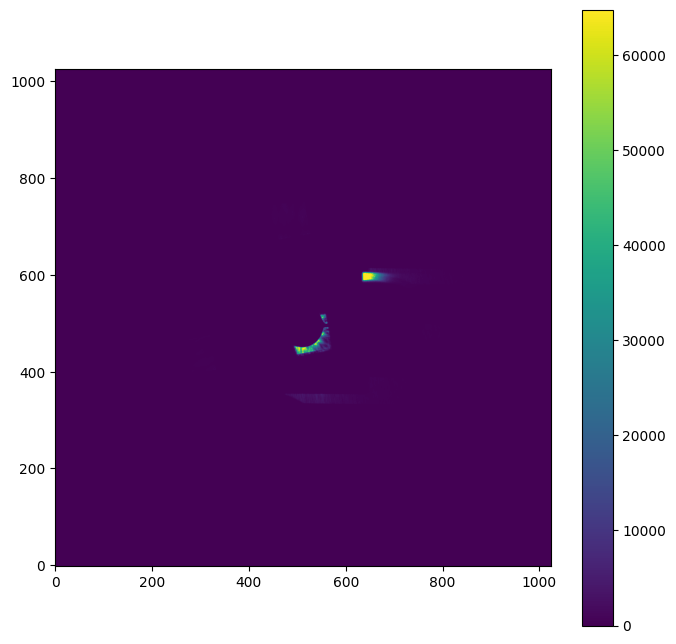

In [6]:
avg_image = np.mean(data, axis=0)

plt.figure(figsize=(8,8))
plt.imshow(avg_image,
           origin="lower",
           cmap="viridis")

plt.colorbar()
plt.show()

In [7]:
def get_temp(filename):

    m = re.search(r'(\d+)K', os.path.basename(filename))

    if m:
        return float(m.group(1))

    return np.nan

temp_files = []

for f in files:

    if "initial" in f.lower() or "after_cooling" in f.lower():

        temp_files.append(f)

temp_files = sorted(temp_files,
                    key=get_temp)

for f in temp_files:
    print(get_temp(f), os.path.basename(f))

300.0 FCGT_initial_300K_10ms_20images_XMCD_e30274f3-4754-4150-a5da-b1c98104b453.h5
300.0 FCGT_initial_300K_10ms_20images_1b7fce69-29b8-4fde-9b79-bd89f6b8310a.h5
300.0 FCGT_after_cooling_300K_10ms_20images_1c09e527-6db8-410d-9802-f8682e159e7b.h5
310.0 FCGT_initial_310K_10ms_20images_591d1f76-b66b-442d-9021-aca08a9cfa9d.h5
320.0 FCGT_initial_320K_10ms_20images_837710c5-d55b-493b-aaa5-289273ca29eb.h5
340.0 FCGT_initial_340K_10ms_20images_b226c14d-e92c-462b-9340-d67db6ac50ff.h5
350.0 FCGT_initial_350K_10ms_20images_073fe2b8-d5e3-45e2-abf1-9e6ad9f244a7.h5
360.0 FCGT_initial_360K_10ms_20images_4a557257-5351-46fc-9727-172c475fb335.h5
365.0 FCGT_initial_365K_50ms_20images_ff58e290-6a97-474a-91ac-860a74328921.h5
370.0 FCGT_initial_370K_50ms_50images_f4b6d775-04fb-413f-84ba-e97811ecfe95.h5
380.0 FCGT_initial_380K_50ms_20images_62faa482-4ffd-4eb7-8f14-59455ce2f750.h5


In [8]:
for file in temp_files:

    with h5py.File(file, "r") as f:

        shape = f[
            "entry1/instrument_1/detector_1/data"
        ].shape

    print(
        f"{get_temp(file):.0f} K",
        shape
    )

300 K (2, 20, 1024, 1024)
300 K (1, 20, 1024, 1024)
300 K (1, 20, 1024, 1024)
310 K (1, 20, 1024, 1024)
320 K (1, 20, 1024, 1024)
340 K (1, 20, 1024, 1024)
350 K (1, 20, 1024, 1024)
360 K (1, 20, 1024, 1024)
365 K (1, 20, 1024, 1024)
370 K (1, 20, 1024, 1024)
380 K (1, 20, 1024, 1024)


In [9]:
xpcs_files = sorted(
    [f for f in files if "XPCS" in f]
)

for i,f in enumerate(xpcs_files):
    print(i, os.path.basename(f))


0 FCGT_300K_50ms_1208readout_1500images_30min_pol_p1_f2f1d6b4-6c94-4b2d-b25d-8cf6e27ecf37.h5
1 FCGT_350K_2D grid scan_23b66967-1fe6-40f4-b0f9-2e48d917429e.h5
2 FCGT_350K_XMCD_9c0cdec4-5d88-486c-b0ce-fd3265702a15.h5
3 FCGT_350K_XPCS_300ms_1900images_640readout_681083c8-1049-4181-92ae-5a89e07969d8.h5
4 FCGT_350K_energy_715_765eV_101steps_8734ab01-7e79-4da8-8d6d-52650664a871.h5
5 FCGT_355K_XPCS_300ms_1900images_640readout_19ccc0d3-79e7-4fd8-b5a3-aefc582d5bc0.h5
6 FCGT_360K_XPCS_300ms_1900images_640readout_cd9caa08-abba-4fcd-be88-7cc2f0a4d36c.h5
7 FCGT_362K_XPCS_300ms_1900images_640readout_a96aa249-fc0b-47ee-90e1-583a86cdb4cb.h5
8 FCGT_363K_XPCS_300ms_1900images_640readout_310d3268-f4c8-48b6-9cb6-9bcc8161909a.h5
9 FCGT_after_cooling_300K_10ms_20images_1c09e527-6db8-410d-9802-f8682e159e7b.h5
10 FCGT_initial_300K_10ms_20images_1b7fce69-29b8-4fde-9b79-bd89f6b8310a.h5
11 FCGT_initial_300K_10ms_20images_XMCD_e30274f3-4754-4150-a5da-b1c98104b453.h5
12 FCGT_initial_310K_10ms_20images_591d1f76-b66

In [10]:
with h5py.File(file, "r") as f:
    dset = f["entry1/instrument_1/detector_1/data"]
    print(dset.shape)
    print(dset.dtype)

(1, 20, 1024, 1024)
uint16


In [11]:
with h5py.File(file, "r") as f:
    dset = f["entry1/instrument_1/detector_1/data"]

    t0 = time.time()
    data = dset[:]
    print("Read time:", time.time() - t0)

    print(data.shape)
    print(data.nbytes/1e9, "GB")

Read time: 0.14277267456054688
(1, 20, 1024, 1024)
0.04194304 GB


In [12]:
with h5py.File(file, "r") as f:
    dset = f["entry1/instrument_1/detector_1/data"]

    print("shape:", dset.shape)
    print("dtype:", dset.dtype)
    print("chunks:", dset.chunks)
    print("compression:", dset.compression)

    nbytes = np.prod(dset.shape) * dset.dtype.itemsize
    print("dataset size (GB):", nbytes/1e9)

shape: (1, 20, 1024, 1024)
dtype: uint16
chunks: None
compression: None
dataset size (GB): 0.04194304


In [13]:
file = xpcs_files[0]

with h5py.File(file, "r") as f:
    data = np.squeeze(
        f["entry1/instrument_1/detector_1/data"][:]
    )

print(data.shape)
print(data.dtype)

(1500, 1024, 1024)
uint16


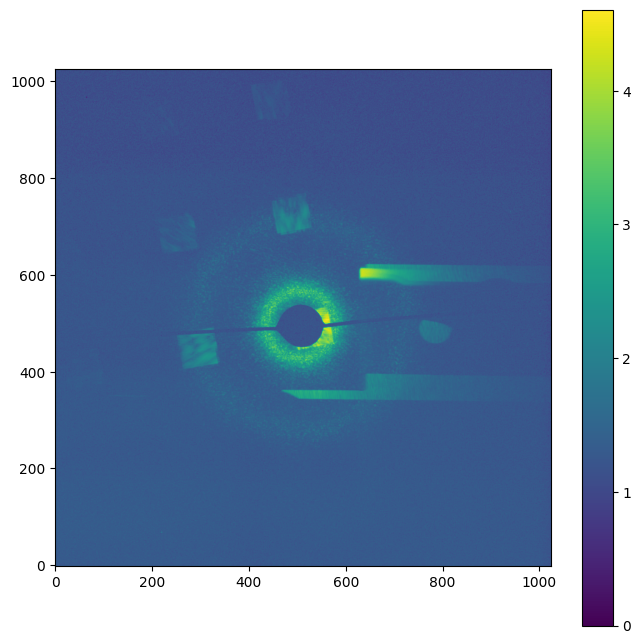

In [14]:
avg = data.mean(axis=0, dtype=np.float64)

plt.figure(figsize=(8,8))
plt.imshow(
    np.log10(avg+1),
    origin="lower"
)
plt.colorbar()
plt.show()

In [15]:
from scipy.ndimage import center_of_mass

threshold = avg > np.percentile(avg,99.9)

cy,cx = center_of_mass(threshold)

print(cx,cy)

589.2707340324118 537.743565300286


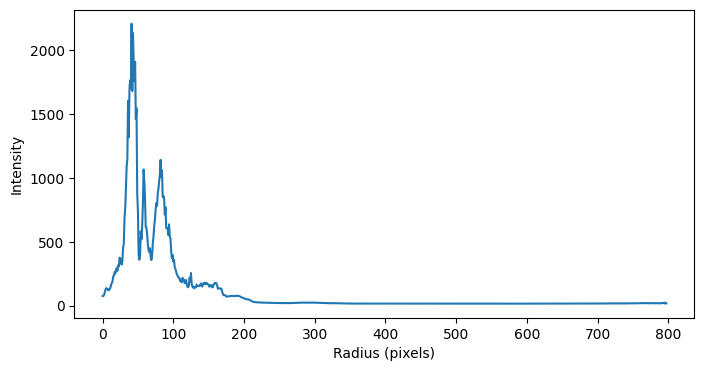

In [16]:
y,x = np.indices(avg.shape)

r = np.sqrt((x-cx)**2 + (y-cy)**2)

r_int = r.astype(int)

radial_sum = np.bincount(
    r_int.ravel(),
    weights=avg.ravel()
)

radial_count = np.bincount(
    r_int.ravel()
)

radial_profile = radial_sum/radial_count

plt.figure(figsize=(8,4))
plt.plot(radial_profile)
plt.xlabel("Radius (pixels)")
plt.ylabel("Intensity")
plt.show()

[41 43 58 82]


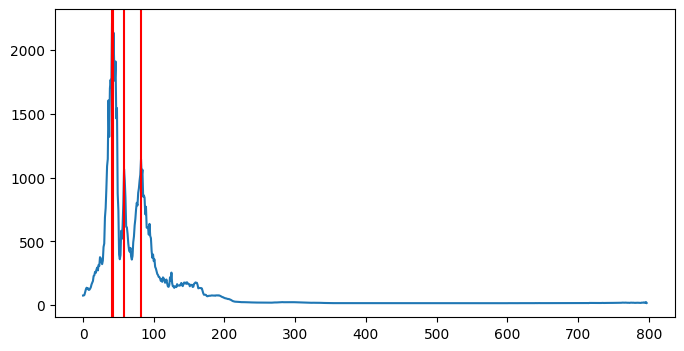

Best radius = 41


In [17]:
from scipy.signal import find_peaks

#can change peak prominance here
peak_prom = 0.20
peaks,_ = find_peaks(
    radial_profile,
    prominence=np.max(radial_profile)*peak_prom
)

print(peaks)

plt.figure(figsize=(8,4))
plt.plot(radial_profile)

for p in peaks:
    plt.axvline(p,color='r')

plt.show()
peak_props = find_peaks(
    radial_profile,
    prominence=np.std(radial_profile)*5
)

peaks = peak_props[0]
prom = peak_props[1]["prominences"]

best_peak = peaks[np.argmax(prom)]

ring_radius = best_peak

print("Best radius =", ring_radius)

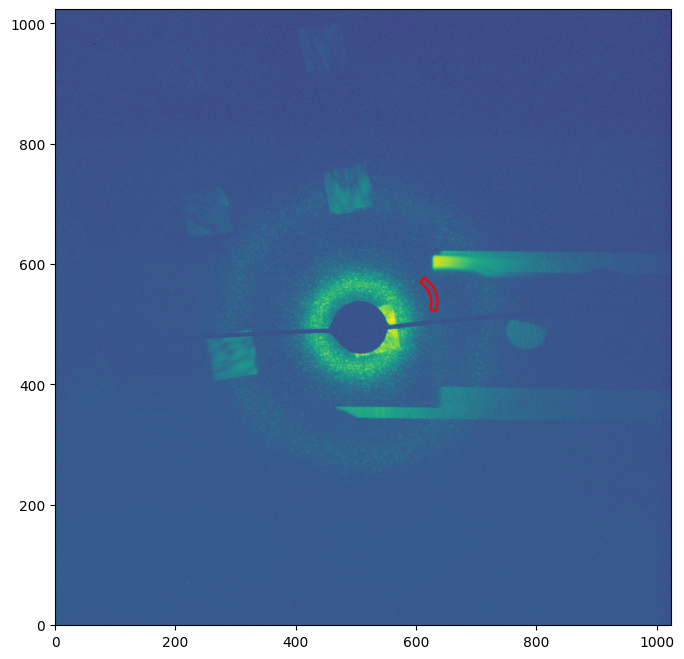

In [19]:
#ring_radius = 41
roi = (
    (r > ring_radius-5) &
    (r < ring_radius+5)
)

theta = np.arctan2(
    y-cy,
    x-cx
)
theta_min = np.radians(-20)
theta_max = np.radians(60)

arc_roi = (
    (r > ring_radius-5) &
    (r < ring_radius+5) &
    (theta > theta_min) &
    (theta < theta_max)
)
plt.figure(figsize=(8,8))

plt.imshow(
    np.log10(avg+1),
    origin="lower"
)

plt.contour(
    arc_roi,
    colors="r",
    linewidths=1.5
)

plt.show()

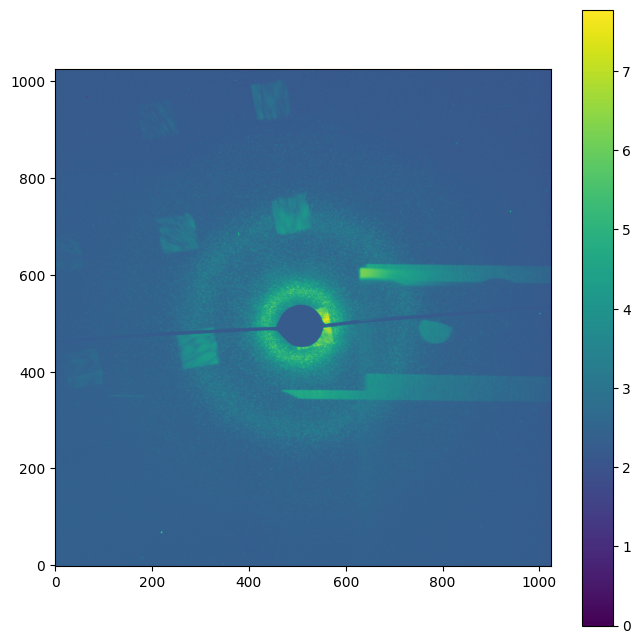

In [20]:
variance_map = data.var(axis=0, dtype=np.float64)

plt.figure(figsize=(8,8))

plt.imshow(
    np.log10(variance_map+1),
    origin="lower")

plt.colorbar()
plt.show()

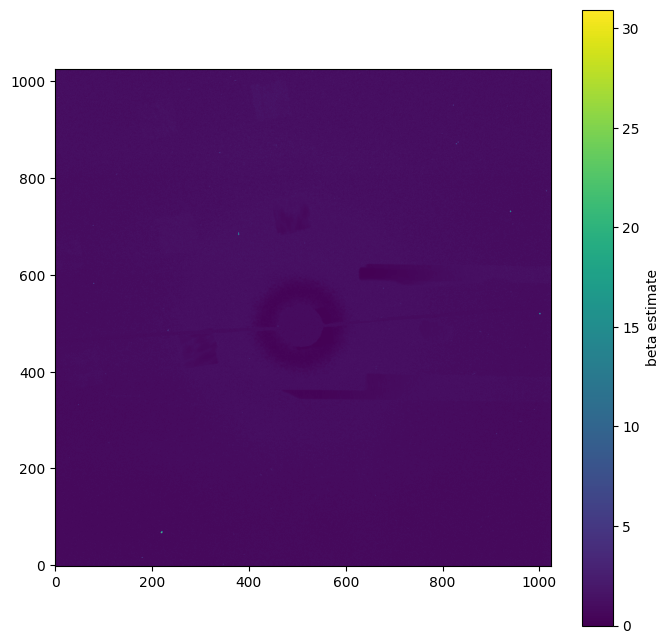

In [21]:
mean_map = np.mean(data,axis=0)

std_map = np.sqrt(variance_map)

contrast = std_map/(mean_map+1e-8)

plt.figure(figsize=(8,8))

plt.imshow(
    contrast,
    origin="lower"
)

plt.colorbar(label="beta estimate")
plt.show()

In [22]:
signal = np.mean(
    data[:,roi],
    axis=1
)

def g2(I):

    N = len(I)

    taus = np.arange(1,N//4)

    g2 = []

    meanI = np.mean(I)

    for tau in taus:

        val = np.mean(
            I[:-tau]*I[tau:]
        )/(meanI**2)

        g2.append(val)

    return taus,np.array(g2)

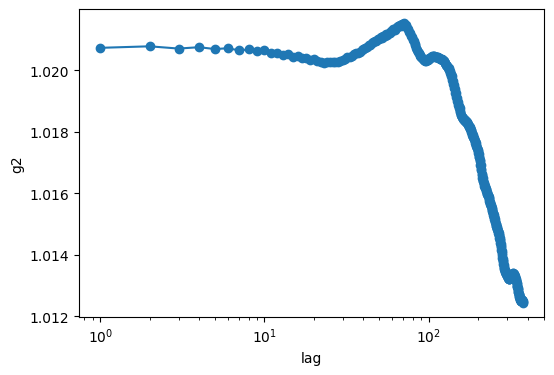

In [23]:
tau,g2curve = g2(signal)

plt.figure(figsize=(6,4))

plt.semilogx(
    tau,
    g2curve,
    'o-'
)

plt.xlabel("lag")
plt.ylabel("g2")
plt.show()

In [49]:
roi.shape == (1024, 1024)
frames = data[0]

signal = np.array([
    np.mean(frame[roi])
    for frame in frames
])
signal.shape
print(data.shape)
print(roi.shape)

frames = np.mean(data, axis=0)

print(frames.shape)
signal = np.array([
    frame[roi].mean()
    for frame in frames
])

print(signal.shape)
print(signal[:5])

(2, 20, 1024, 1024)
(1024, 1024)
(20, 1024, 1024)
(20,)
[1905.79343179 1971.04547221 1951.74893121 1996.80586864 1957.35231248]


In [54]:
print("data:", data.shape)

frames = np.mean(data, axis=0)

print("frames:", frames.shape)
print("first frame:", frames[0].shape)

print("roi type:", type(roi))

try:
    print("roi shape:", roi.shape)
except:
    pass

try:
    print("roi dtype:", roi.dtype)
except:
    pass

data: (20, 1024, 1024)
frames: (1024, 1024)
first frame: (1024,)
roi type: <class 'numpy.ndarray'>
roi shape: (1024, 1024)
roi dtype: bool


In [58]:
print("data shape =", data.shape)

frames = data

print("frames shape =", frames.shape)
print("frames[0] shape =", frames[0].shape)

print("roi shape =", roi.shape)

data shape = (2, 20, 1024, 1024)
frames shape = (2, 20, 1024, 1024)
frames[0] shape = (20, 1024, 1024)
roi shape = (1024, 1024)


In [63]:
with h5py.File(file, "r") as f:

    data = np.squeeze(
        f["entry1/instrument_1/detector_1/data"][:]
    ).astype(float)

# average the two polarizations
frames = np.mean(data, axis=0)

signal = np.array([
    np.mean(frame[roi])
    for frame in frames
])
print("data", data.shape)
print("frames", frames.shape)
print("signal", signal.shape)
tau, g2curve = g2(signal)

data (2, 20, 1024, 1024)
frames (20, 1024, 1024)
signal (20,)


In [62]:
#plot g2 curves for all temperatures

plt.figure(figsize=(8,6))

for file in temp_files:

    with h5py.File(file, "r") as f:

        data = np.squeeze(
            f["entry1/instrument_1/detector_1/data"][:]
        ).astype(float)

    #frames have shape (20,1024,1024)
    frames = data

    #ROI intensity vs time
    signal = np.array([
        frame[roi].mean()
        for frame in frames
    ])

    tau, g2curve = g2(signal)

    temp = get_temp(file)

    print(
        temp,
        signal.mean(),
        signal.std()
    )
    print(temp, signal.mean(), signal.std())
    plt.semilogx(
        tau,
        g2curve,
        label=f"{temp:.0f} K"
    )

plt.xlabel("Lag")
plt.ylabel("g₂")
plt.title("g₂ Comparison vs Temperature")
plt.legend()
plt.show()

IndexError: boolean index did not match indexed array along dimension 0; dimension is 20 but corresponding boolean dimension is 1024

<Figure size 800x600 with 0 Axes>

In [24]:
theta = np.arctan2(
    y-cy,
    x-cx
)

ring_mask = (
    (r > ring_radius-5) &
    (r < ring_radius+5)
)

angles = np.linspace(
    -np.pi,
    np.pi,
    360
)

intensity = np.zeros(len(angles)-1)

for i in range(len(angles)-1):

    mask = (
        ring_mask &
        (theta>=angles[i]) &
        (theta<angles[i+1])
    )

    intensity[i] = np.mean(avg[mask])

C:\Users\roadr\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\roadr\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


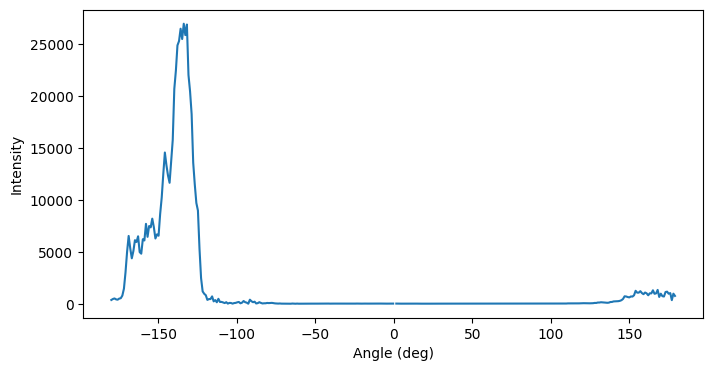

In [25]:
plt.figure(figsize=(8,4))

plt.plot(
    np.degrees(angles[:-1]),
    intensity
)

plt.xlabel("Angle (deg)")
plt.ylabel("Intensity")
plt.show()

In [26]:
print(os.path.basename(file))
print("data shape =", data.shape)

avg = np.mean(data, axis=0)

print("avg shape =", avg.shape)
print()

FCGT_300K_50ms_1208readout_1500images_30min_pol_p1_f2f1d6b4-6c94-4b2d-b25d-8cf6e27ecf37.h5
data shape = (1500, 1024, 1024)
avg shape = (1024, 1024)



In [27]:
temps = []
ring_intensity = []

for file in temp_files:

    with h5py.File(file,"r") as f:

        data = np.squeeze(
            f["entry1/instrument_1/detector_1/data"][:]
        )

    avg = np.mean(data,axis=0)

    temps.append(
        get_temp(file)
    )

    ring_intensity.append(
        np.mean(avg[roi])
    )

IndexError: boolean index did not match indexed array along dimension 0; dimension is 20 but corresponding boolean dimension is 1024

ValueError: x and y must have same first dimension, but have shapes (1,) and (0,)

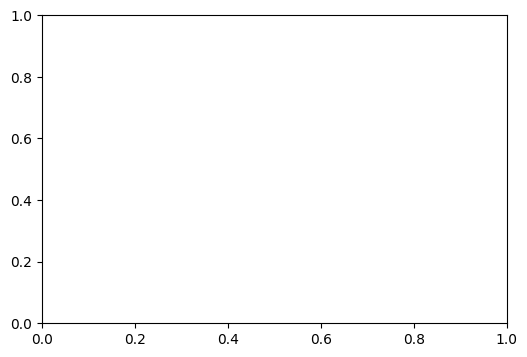

In [28]:
plt.figure(figsize=(6,4))

plt.plot(
    temps,
    ring_intensity,
    'o-'
)

plt.xlabel("Temperature (K)")
plt.ylabel("Ring intensity")

plt.show()